# Cointegration Testing

Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

### Step 1: Define formation window and extract data
We will define 2016-01-01 as the end of the formation window and extract the previous 2 years of trading data (504 trading days).

In [2]:
formation_end = pd.Timestamp("2016-01-01")
window_size = 504

In [3]:
data_folder_path = Path("data")

membership_file_path = data_folder_path / "membership_df.csv"

print(data_folder_path.exists())

True


Extract list of S&P tickers at formation end

In [4]:
formatted_date = formation_end.strftime('%Y%m')
membership_df = pd.read_csv(membership_file_path)
end_membership = membership_df[formatted_date].dropna().to_list()

In [5]:
print(end_membership)

['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'ADT', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN', 'AIG', 'AIV', 'AIZ', 'AKAM', 'ALL', 'ALLE', 'ALXN', 'AMAT', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'AN', 'ANDV', 'AON', 'APA', 'APC', 'APD', 'APH', 'APTV', 'ARG', 'ATVI', 'AVB', 'AVGO', 'AVY', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBBY', 'BBWI', 'BBY', 'BCR', 'BDX', 'BEN', 'BF-B', 'BHI', 'BIIB', 'BK', 'BKNG', 'BLK', 'BMY', 'BRCM', 'BRK-B', 'BSX', 'BWA', 'BXLT', 'BXP', 'C', 'CA', 'CAG', 'CAH', 'CAM', 'CAT', 'CB', 'CBRE', 'CCE', 'CCI', 'CCL', 'CELG', 'CERN', 'CF', 'CHD', 'CHK', 'CHRW', 'CI', 'CINF', 'CL', 'CLX', 'CMA', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNP', 'CNX', 'COF', 'COL', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPGX', 'CPRI', 'CRM', 'CSCO', 'CSRA', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTXS', 'CVC', 'CVS', 'CVX', 'D', 'DAL', 'DAY', 'DD', 'DE', 'DFS', 'DG', 'DGX', 'DHI', 'DHR', 'DIS', 'DISCA', 'DISCK', 'DLTR', 'DNB', 'DO', 'DOC',

Get price data for window

In [6]:
historical_ohlcv_df = pd.read_parquet(data_folder_path / "historical_ohlcv_df.parquet")

In [7]:
print(historical_ohlcv_df.head())

Ticker     SOLV                       KVUE                        ...  \
Price      Open High Low Close Volume Open High Low Close Volume  ...   
Date                                                              ...   
2014-01-02  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...   
2014-01-03  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...   
2014-01-06  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...   
2014-01-07  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...   
2014-01-08  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...   

Ticker              R                                                 EOG  \
Price            Open       High        Low      Close  Volume       Open   
Date                                                                        
2014-01-02  51.244708  51.384891  50.683965  50.915272  453500  59.113503   
2014-01-03  51.055471  51.335842  50.838185  51.020428  303500  58.822462   
2014-01-06  51.265752  51.4479

In [8]:
print(historical_ohlcv_df)

Ticker           SOLV                                                  KVUE  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2014-01-02        NaN        NaN        NaN        NaN       NaN        NaN   
2014-01-03        NaN        NaN        NaN        NaN       NaN        NaN   
2014-01-06        NaN        NaN        NaN        NaN       NaN        NaN   
2014-01-07        NaN        NaN        NaN        NaN       NaN        NaN   
2014-01-08        NaN        NaN        NaN        NaN       NaN        NaN   
...               ...        ...        ...        ...       ...        ...   
2025-12-24  80.459999  80.699997  80.010002  80.180000  398100.0  16.230158   
2025-12-26  80.250000  80.559998  79.862000  80.459999  502400.0  16.392458   
2025-12-29  80.519997  80.970001  79.989998  80.089996  575200.0  16.430645   
2025-12-30  79.910004  80.620003  79.500000  80.1600

Extract data in formation window

In [9]:
formation_data = formation_data = historical_ohlcv_df.loc[
    historical_ohlcv_df.index < formation_end
].tail(window_size)

Keep only tickers present at formation end

In [10]:
formation_data = formation_data.loc[:, formation_data.columns.get_level_values(0).isin(end_membership)]

Extract close prices for cointegration

In [11]:
formation_close_df = formation_data.xs('Close', axis=1, level=1)

In [12]:
print(formation_close_df.head())

Ticker      SNI  LLL  WBA       CBRE  ADT        IQV      KLAC        SW  \
Date                                                                       
2014-01-02  NaN  NaN  NaN  26.340000  NaN  45.799999  3.997444  16.12015   
2014-01-03  NaN  NaN  NaN  26.400000  NaN  46.290001  4.003122  16.12015   
2014-01-06  NaN  NaN  NaN  26.250000  NaN  46.029999  3.933112  16.12015   
2014-01-07  NaN  NaN  NaN  26.190001  NaN  46.790001  3.931221  16.12015   
2014-01-08  NaN  NaN  NaN  26.190001  NaN  47.419998  3.929329  16.12015   

Ticker            AMT  SYF  ...  AGN        CME        GIS        CAG  \
Date                        ...                                         
2014-01-02  58.898232  NaN  ...  NaN  47.224113  31.121460  16.424904   
2014-01-03  59.068741  NaN  ...  NaN  47.975243  31.033251  16.385775   
2014-01-06  59.446808  NaN  ...  NaN  47.490654  31.083658  16.307476   
2014-01-07  60.269669  NaN  ...  NaN  47.139320  31.404943  16.586372   
2014-01-08  60.744110  NaN  .

Get number of columns before removing any

In [13]:
num_cols_before = len(formation_close_df.columns)
print(num_cols_before)

508


Remove columns where <= 90% of the expected observation data is present

In [14]:
min_observations = int(len(formation_close_df) * 0.90)

formation_close_df = formation_close_df.dropna(
    axis=1,
    thresh=min_observations
)

In [15]:
num_cols_after = len(formation_close_df.columns.tolist())
print(f"{num_cols_after/num_cols_before:.2%} of columns remain after dropping columns with less than {min_observations} observations.")

77.56% of columns remain after dropping columns with less than 453 observations.


### Step 2: Filter uncorrelated pairs before cointegration testing

Calculate percent changes in closing prices from one trading day to another

In [16]:
returns = formation_close_df.pct_change().dropna()
print (returns.head())

Ticker          CBRE       IQV      KLAC   SW       AMT      SWKS       BAC  \
Date                                                                          
2014-01-03  0.002278  0.010699  0.001420  0.0  0.002895  0.011679  0.019254   
2014-01-06 -0.005682 -0.005617 -0.017489  0.0  0.006400 -0.003247  0.015235   
2014-01-07 -0.002286  0.016511 -0.000481  0.0  0.013842  0.005791 -0.009604   
2014-01-08  0.000000  0.013464 -0.000481  0.0  0.007872  0.004678  0.004849   
2014-01-09 -0.001527  0.008857  0.003050  0.0  0.001953 -0.007164  0.015079   

Ticker          PRGO       STT      TSCO  ...        DD       CME       GIS  \
Date                                      ...                                 
2014-01-03  0.007381  0.021050 -0.004167  ... -0.004559  0.015906 -0.002834   
2014-01-06 -0.008429 -0.000134 -0.013337  ... -0.001833 -0.010101  0.001624   
2014-01-07  0.010790  0.007364  0.006228  ... -0.011011 -0.007398  0.010336   
2014-01-08  0.022318 -0.002525  0.005532  ...  0.00

In [17]:
correlation_matrix = returns.corr()
print(correlation_matrix)

Ticker      CBRE       IQV      KLAC        SW       AMT      SWKS       BAC  \
Ticker                                                                         
CBRE    1.000000  0.346145  0.317904 -0.011873  0.539964  0.336814  0.466449   
IQV     0.346145  1.000000  0.226973  0.054309  0.322283  0.361105  0.377233   
KLAC    0.317904  0.226973  1.000000 -0.005439  0.263689  0.432505  0.345866   
SW     -0.011873  0.054309 -0.005439  1.000000 -0.053218  0.020364  0.040019   
AMT     0.539964  0.322283  0.263689 -0.053218  1.000000  0.265644  0.363251   
...          ...       ...       ...       ...       ...       ...       ...   
NSC     0.396083  0.296697  0.374862 -0.038243  0.351497  0.333085  0.430775   
A       0.487968  0.434789  0.413204 -0.013651  0.446757  0.479207  0.555244   
WY      0.506506  0.299252  0.307028 -0.030570  0.532578  0.280652  0.349029   
R       0.482470  0.339828  0.430091  0.002283  0.439035  0.431590  0.534410   
EOG     0.356338  0.237552  0.298735 -0.

Select for only pairs where p > 0.7. We will only perform cointegration testing on this correlated set.

In [18]:
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)) # select upper triangle since matrix is symmetric; ensure no duplicates pairs are considered
high_corr_pairs = (upper_triangle.stack().loc[lambda x: x > 0.7])
filtered_pairs = high_corr_pairs.index.tolist()

print(filtered_pairs)

[('SWKS', 'AVGO'), ('BAC', 'STT'), ('BAC', 'HBAN'), ('BAC', 'PFG'), ('BAC', 'TFC'), ('BAC', 'RF'), ('BAC', 'KEY'), ('BAC', 'AMP'), ('BAC', 'C'), ('BAC', 'FITB'), ('BAC', 'GS'), ('BAC', 'PNC'), ('BAC', 'JPM'), ('BAC', 'MET'), ('BAC', 'MTB'), ('BAC', 'ZION'), ('BAC', 'USB'), ('BAC', 'UNM'), ('BAC', 'NTRS'), ('BAC', 'MS'), ('BAC', 'LNC'), ('BAC', 'WFC'), ('BAC', 'PRU'), ('BAC', 'SCHW'), ('STT', 'HBAN'), ('STT', 'TROW'), ('STT', 'PFG'), ('STT', 'BEN'), ('STT', 'TFC'), ('STT', 'RF'), ('STT', 'KEY'), ('STT', 'AMP'), ('STT', 'C'), ('STT', 'GS'), ('STT', 'PNC'), ('STT', 'JPM'), ('STT', 'BLK'), ('STT', 'MET'), ('STT', 'USB'), ('STT', 'NTRS'), ('STT', 'IVZ'), ('STT', 'MS'), ('STT', 'LNC'), ('STT', 'MRSH'), ('STT', 'WFC'), ('STT', 'PRU'), ('STT', 'SCHW'), ('COP', 'DVN'), ('COP', 'XOM'), ('COP', 'CVX'), ('COP', 'APA'), ('COP', 'HAL'), ('COP', 'HP'), ('COP', 'MUR'), ('COP', 'OXY'), ('COP', 'SLB'), ('COP', 'EOG'), ('DVN', 'CVX'), ('DVN', 'APA'), ('DVN', 'HP'), ('DVN', 'MUR'), ('DVN', 'OXY'), ('DVN',

Perform cointegration testing on filtered pairs

In [19]:
log_prices = np.log(formation_close_df)
threshold = 0.05 # select the significance level for the cointegration test
cointegrated_pairs = []
for pair in filtered_pairs:
    ticker_0, ticker_1 = pair
    log_pair_prices = log_prices[[pair[0], pair[1]]]
    coint_t, p_value, critical_values = coint(log_prices[ticker_0], log_prices[ticker_1])
    if p_value < threshold:
        cointegrated_pairs.append(pair)

print("Cointegrated pairs:", cointegrated_pairs)

    

Cointegrated pairs: [('STT', 'GS'), ('STT', 'MS'), ('STT', 'LNC'), ('COP', 'EOG'), ('KIM', 'O'), ('PNW', 'ES'), ('ITW', 'MMM'), ('HBAN', 'PNC'), ('HBAN', 'JPM'), ('HBAN', 'NTRS'), ('GL', 'AIG'), ('GL', 'L'), ('CVX', 'EOG'), ('TFC', 'KEY'), ('TFC', 'C'), ('TFC', 'GS'), ('TFC', 'PNC'), ('TFC', 'JPM'), ('TFC', 'UNM'), ('TFC', 'NTRS'), ('TFC', 'MS'), ('RF', 'AMP'), ('RF', 'FITB'), ('RF', 'GS'), ('RF', 'PNC'), ('RF', 'JPM'), ('RF', 'ZION'), ('RF', 'NTRS'), ('RF', 'MS'), ('RF', 'WFC'), ('RF', 'PRU'), ('C', 'HIG'), ('C', 'GS'), ('C', 'PNC'), ('C', 'NTRS'), ('C', 'WFC'), ('C', 'SCHW'), ('ES', 'PCG'), ('FITB', 'ZION'), ('APA', 'OXY'), ('APA', 'EOG'), ('D', 'PEG'), ('D', 'DTE'), ('D', 'SO'), ('D', 'EIX'), ('PNC', 'JPM'), ('PNC', 'SCHW'), ('AIV', 'ESS'), ('AEP', 'DTE'), ('AEP', 'NEE'), ('XEL', 'CMS'), ('XEL', 'PCG'), ('JPM', 'NTRS'), ('JPM', 'SCHW'), ('V', 'MA'), ('FLR', 'FLS'), ('O', 'SPG'), ('MTB', 'USB'), ('MTB', 'NTRS'), ('MTB', 'WFC'), ('MTB', 'SCHW'), ('PH', 'CMI'), ('CMS', 'PCG'), ('PCG', 

### Step 3: Perform these calculations while sliding the window

Create a function to perform these calculations for a given window

In [20]:
# Note: do not apply significance filtering here.
# We need all cointegration-test p-values for Benjamini-Hochberg correction later.
def test_cointegration_window(formation_end, window_size=504, obs_threshold = 0.90, corr_threshold=0.7):
    formation_data = historical_ohlcv_df.loc[
        historical_ohlcv_df.index < formation_end
    ].tail(window_size)

    formatted_date = formation_end.strftime('%Y%m')
    end_membership = membership_df[formatted_date].dropna().to_list()
    formation_data = formation_data.loc[:, formation_data.columns.get_level_values(0).isin(end_membership)]

    formation_close_df = formation_data.xs('Close', axis=1, level=1)
    
    min_observations = int(len(formation_close_df) * obs_threshold)

    formation_close_df = formation_close_df.dropna(
        axis=1,
        thresh=min_observations
    )

    # Correlation filtering
    returns = formation_close_df.pct_change(fill_method=None)
    correlation_matrix = returns.corr()

    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)) # select upper triangle since matrix is symmetric; ensure no duplicates pairs are considered
    high_corr_pairs = (upper_triangle.stack().loc[lambda x: x > corr_threshold])
    filtered_pairs = high_corr_pairs.index.tolist()

    # Cointegration testing
    log_prices = np.log(formation_close_df)
    coint_results = []
    for ticker_0, ticker_1 in filtered_pairs:
        log_pair_prices = log_prices[[ticker_0, ticker_1]].dropna()
        coint_t, p_value, critical_values = coint(log_pair_prices[ticker_0], log_pair_prices[ticker_1])
        coint_results.append({
            "formation_end": formation_end,
            "ticker_0": ticker_0,
            "ticker_1": ticker_1,
            "correlation": correlation_matrix.loc[ticker_0, ticker_1],
            "coint_t": coint_t,
            "p_value": p_value,
            "critical_1pct": critical_values[0],
            "critical_5pct": critical_values[1],
            "critical_10pct": critical_values[2],
            "n_observations": len(log_pair_prices)
        })

    return pd.DataFrame(coint_results)

Testing function

In [21]:
results = test_cointegration_window(pd.Timestamp("2016-01-01"))

results.head()

,formation_end,ticker_0,ticker_1,correlation,coint_t,p_value,critical_1pct,critical_5pct,critical_10pct,n_observations
0,2016-01-01,SWKS,AVGO,0.705393,-1.002936,0.902289,-3.918346,-3.348304,-3.052893,504
1,2016-01-01,BAC,STT,0.730833,-2.457938,0.297928,-3.918346,-3.348304,-3.052893,504
2,2016-01-01,BAC,HBAN,0.767496,-2.619432,0.229075,-3.918346,-3.348304,-3.052893,504
3,2016-01-01,BAC,PFG,0.710855,-2.254301,0.396564,-3.918346,-3.348304,-3.052893,504
4,2016-01-01,BAC,TFC,0.756456,-2.554400,0.255618,-3.918346,-3.348304,-3.052893,504


Execute this function while sliding the window

In [ ]:
formation_end = pd.Timestamp("2016-01-01")
final_date = pd.Timestamp("2026-01-01")

results = []
while formation_end <= final_date:
    results.append(test_cointegration_window(formation_end))
    formation_end += pd.DateOffset(months=1) # offset by one month (unlikely to use a trading window smaller than this)

all_results = pd.concat(results, ignore_index=True)

all_results = all_results.set_index(['formation_end', 'ticker_0', 'ticker_1'])

In [23]:
all_results.to_parquet(data_folder_path / "cointegration_results.parquet")

In [24]:
print(all_results.head())

                                 correlation   coint_t   p_value  \
formation_end ticker_0 ticker_1                                    
2016-01-01    SWKS     AVGO         0.705393 -1.002936  0.902289   
              BAC      STT          0.730833 -2.457938  0.297928   
                       HBAN         0.767496 -2.619432  0.229075   
                       PFG          0.710855 -2.254301  0.396564   
                       TFC          0.756456 -2.554400  0.255618   

                                 critical_1pct  critical_5pct  critical_10pct  \
formation_end ticker_0 ticker_1                                                 
2016-01-01    SWKS     AVGO          -3.918346      -3.348304       -3.052893   
              BAC      STT           -3.918346      -3.348304       -3.052893   
                       HBAN          -3.918346      -3.348304       -3.052893   
                       PFG           -3.918346      -3.348304       -3.052893   
                       TFC           

Analyze results with significance filtering.

In [25]:
sig_results = all_results[all_results["p_value"] < 0.05] # threshold = 0.05

In [26]:
sig_results.to_parquet(data_folder_path / "sig_results.parquet")

View stats on pairs that met the significance threshold

In [27]:
# Since window size is constant, we identify a window by the month of its formation end date.
pairs_per_month = sig_results.groupby(level="formation_end").size()

pairs_per_month.describe()

count     121.000000
mean      138.553719
std       166.671631
min        21.000000
25%        48.000000
50%        76.000000
75%       118.000000
max      1006.000000
dtype: float64

The max is significantly greater than the average number of pairs. Plot the number of significant pairs per formation window over time to visually inspect this result.

<Axes: title={'center': 'Cointegrated Pairs per Formation Window'}, xlabel='formation_end'>

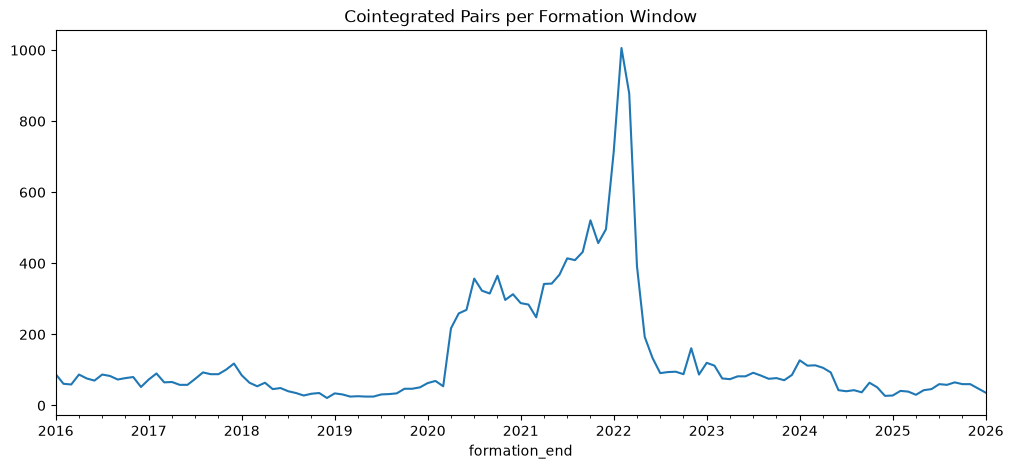

In [28]:
pairs_per_month.plot(title="Cointegrated Pairs per Formation Window", figsize=(12, 5))

Based on this graph, it seems plausible that market conditions during the COVID-19 pandemic caused several S&P 500 pairs to temporarily appear more cointegrated. This suggests that using a correction method like the Benjamini-Hochberg Procedure may be appropriate to limit the number of false discoveries. We will implement this with a target false discovery rate of 0.05.

Define a function to apply Benjamini-Hochberg correction to a group of p-values

In [29]:
def apply_bh(group):
    reject, p_adj, _, _ = multipletests(group["p_value"], alpha=0.05, method='fdr_bh')
    group = group.copy()
    group["bh_reject"] = reject
    group["bh_p_value"] = p_adj
    return group

Apply this function to each formation window group

In [30]:
all_results_bh = all_results.groupby(level="formation_end", group_keys=False).apply(apply_bh)

Save to parquet

In [31]:
all_results_bh.to_parquet(data_folder_path / "bh_corrected_results.parquet")

<Axes: title={'center': 'BH-Significant Cointegrated Pairs per Formation Window'}, xlabel='formation_end'>

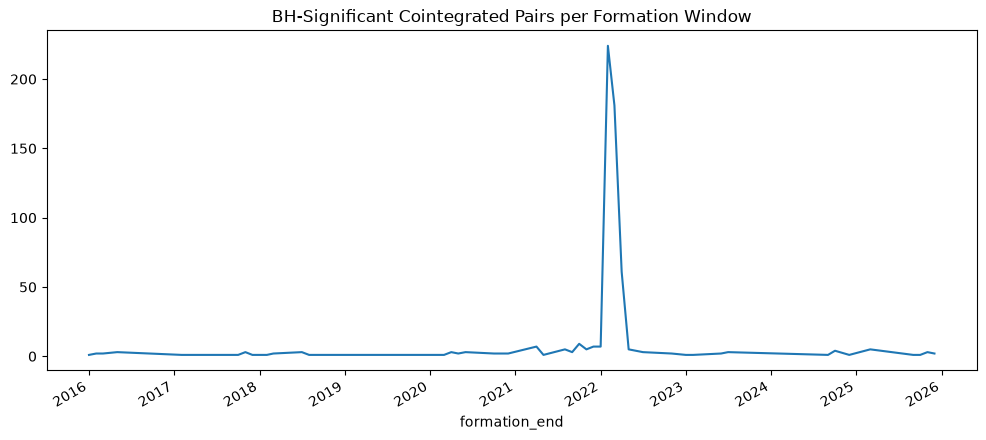

In [32]:
pairs_per_month_bh = all_results_bh[all_results_bh['bh_reject']].groupby(level="formation_end").size()
pairs_per_month_bh.plot(title="BH-Significant Cointegrated Pairs per Formation Window", figsize=(12, 5))

The results after BH correction are somewhat unusual. For most windows, very few pairs survived correction, but there is a dramatic spike in early 2022. It is not immediately clear whether this is primarily due to market conditions, properties of the cointegration test, or a feature of the screening process. Rather than investigating this further, I will perform backtesting using both the raw significance-threshold set and the BH-corrected set and compare their results.